## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import re
import math
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregamento do Dataset

In [2]:
df = pd.read_csv('urldata_normalized.csv')
print(f'Linhas  : {df.shape[0]:,}')
print(f'Colunas : {df.shape[1]}')

Linhas  : 95,911
Colunas : 14


## 3. Listas de Referência

Definimos as listas usadas nos indicadores binários.

In [3]:
ENCURTADORES = {
    'bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly',
    'is.gd', 'buff.ly', 'adf.ly', 'short.link', 'rebrand.ly', 'tiny.cc'
}

TLDS_SUSPEITOS = {
    'tk', 'ml', 'ga', 'cf', 'gq',
    'xyz', 'top', 'club', 'work', 'info',
    'biz', 'click', 'link', 'online', 'site', 'website'
}

PALAVRAS_SUSPEITAS = [
    'login', 'verify', 'secure', 'update', 'bank', 'paypal',
    'account', 'password', 'confirm', 'validate', 'signin',
    'wallet', 'billing', 'support', 'alert', 'security'
]

print(f'Encurtadores   : {len(ENCURTADORES)}')
print(f'TLDs suspeitos : {len(TLDS_SUSPEITOS)}')
print(f'Palavras susp. : {len(PALAVRAS_SUSPEITAS)}')

Encurtadores   : 11
TLDs suspeitos : 16
Palavras susp. : 16


## 4. Função de Extração — 27 Features

In [4]:
def calcular_entropia(texto):
    """Entropia de Shannon — mede a aleatoriedade de uma string."""
    if not texto: return 0.0
    f = {}
    for c in texto:
        f[c] = f.get(c, 0) + 1
    e = 0.0
    for v in f.values():
        p = v / len(texto)
        e -= p * math.log2(p)
    return round(e, 4)


def extrair_features_v2(url):
    """Extrai 27 características lexicais de um URL."""
    url = str(url).strip()
    if not url.startswith(('http://', 'https://')):
        parsed = urlparse('http://' + url)
    else:
        parsed = urlparse(url)

    dominio       = parsed.netloc or parsed.path.split('/')[0]
    dominio_limpo = dominio.replace('www.', '')
    path          = parsed.path
    query         = parsed.query
    esquema       = parsed.scheme
    partes_dom    = dominio_limpo.split('.')
    tld           = partes_dom[-1].lower() if len(partes_dom) > 1 else ''
    porto         = parsed.port
    url_lower     = url.lower()

    comp_url     = len(url)
    n_digitos    = sum(c.isdigit() for c in url)
    n_hifenes    = url.count('-')
    n_underscore = url.count('_')
    n_percent    = url.count('%')
    n_iguais     = url.count('=')

    return {
        # ── Comprimentos ──────────────────────────────────────
        'lex_comp_url'            : comp_url,
        'lex_comp_dominio'        : len(dominio),
        'lex_comp_path'           : len(path),
        # ── Contagens de caracteres ────────────────────────────
        'lex_n_pontos'            : url.count('.'),
        'lex_n_hifenes'           : n_hifenes,
        'lex_n_subdominios'       : max(0, len(dominio.split('.')) - 2),
        'lex_n_digitos'           : n_digitos,
        'lex_n_barras'            : url.count('/'),
        'lex_n_iguais'            : n_iguais,
        'lex_n_ampersands'        : url.count('&'),
        'lex_n_percent'           : n_percent,
        'lex_n_underscores'       : n_underscore,
        'lex_n_params'            : len([p for p in query.split('&') if p]),
        # ── Rácios ────────────────────────────────────────────
        'lex_ratio_digitos'       : round(n_digitos / comp_url, 4) if comp_url > 0 else 0,
        'lex_ratio_especiais'     : round((n_hifenes + n_underscore + n_percent + n_iguais) / comp_url, 4) if comp_url > 0 else 0,
        # ── Estrutura ─────────────────────────────────────────
        'lex_profundidade'        : len([p for p in path.split('/') if p]),
        # ── Indicadores binários ──────────────────────────────
        'lex_tem_https'           : 1 if esquema == 'https' else 0,
        'lex_tem_ip'              : 1 if re.match(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', dominio) else 0,
        'lex_tem_arroba'          : 1 if '@' in url else 0,
        'lex_tem_http_no_path'    : 1 if 'http' in path.lower() else 0,
        'lex_tld_suspeito'        : 1 if tld in TLDS_SUSPEITOS else 0,
        'lex_encurtador'          : 1 if any(e in url_lower for e in ENCURTADORES) else 0,
        'lex_porto_suspeito'      : 1 if (porto and porto not in {80, 443, 8080}) else 0,
        'lex_digitos_consecutivos': 1 if re.search(r'\d{3,}', dominio_limpo) else 0,
        # ── Conteúdo semântico ────────────────────────────────
        'lex_palavras_suspeitas'  : sum(1 for p in PALAVRAS_SUSPEITAS if p in url_lower),
        # ── Entropia ──────────────────────────────────────────
        'lex_entropia_dominio'    : calcular_entropia(dominio_limpo),
        'lex_entropia_url'        : calcular_entropia(url),
    }

# Teste com exemplos reais
testes = [
    ('google.com', 'Benigno'),
    ('github.com/scikit-learn/scikit-learn', 'Benigno'),
    ('www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home', 'Malicioso'),
    ('serviciosbys.com/paypal.cgi.bin.get-into.herf.secure/index.php', 'Malicioso'),
]
print(f'Features extraidas: {len(extrair_features_v2("test.com"))}\n')
for url, label in testes:
    f = extrair_features_v2(url)
    print(f'[{label}] {url[:55]}')
    print(f'  comp={f["lex_comp_url"]:3d} | digitos={f["lex_n_digitos"]:3d} | '
          f'entropia_dom={f["lex_entropia_dominio"]:.2f} | '
          f'palavras_susp={f["lex_palavras_suspeitas"]} | '
          f'ratio_dig={f["lex_ratio_digitos"]:.3f}')
    print()

Features extraidas: 27

[Benigno] google.com
  comp= 10 | digitos=  0 | entropia_dom=2.65 | palavras_susp=0 | ratio_dig=0.000

[Benigno] github.com/scikit-learn/scikit-learn
  comp= 36 | digitos=  0 | entropia_dom=3.32 | palavras_susp=0 | ratio_dig=0.000

[Malicioso] www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home
  comp= 54 | digitos=  0 | entropia_dom=3.10 | palavras_susp=1 | ratio_dig=0.000

[Malicioso] serviciosbys.com/paypal.cgi.bin.get-into.herf.secure/in
  comp= 62 | digitos=  0 | entropia_dom=3.33 | palavras_susp=2 | ratio_dig=0.000



## 5. Aplicação ao Dataset Completo

In [5]:
print('A extrair 27 features de cada URL... (pode demorar 1-2 minutos)')

features_df = df['domain'].apply(extrair_features_v2).apply(pd.Series)

print(f'Concluido!')
print(f'Novas colunas geradas: {len(features_df.columns)}')

A extrair 27 features de cada URL... (pode demorar 1-2 minutos)
Concluido!
Novas colunas geradas: 27


In [6]:
df_final = pd.concat([df, features_df], axis=1)

print(f'Dataset original : {df.shape}')
print(f'Dataset final    : {df_final.shape}')

Dataset original : (95911, 14)
Dataset final    : (95911, 41)


## 6. Verificação

In [7]:
print('Estatisticas das 27 features lexicais:')
df_final[features_df.columns].describe().round(3)

Estatisticas das 27 features lexicais:


,lex_comp_url,lex_comp_dominio,lex_comp_path,lex_n_pontos,lex_n_hifenes,lex_n_subdominios,lex_n_digitos,lex_n_barras,lex_n_iguais,lex_n_ampersands,...,lex_tem_ip,lex_tem_arroba,lex_tem_http_no_path,lex_tld_suspeito,lex_encurtador,lex_porto_suspeito,lex_digitos_consecutivos,lex_palavras_suspeitas,lex_entropia_dominio,lex_entropia_url
count,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,...,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000,95911.000
mean,64.459,22.351,25.835,3.269,0.656,1.342,8.168,2.975,0.427,0.219,...,0.000,0.002,0.003,0.018,0.060,0.001,0.082,0.404,3.378,4.205
std,64.945,23.389,26.017,2.330,1.518,1.962,19.403,1.953,1.158,0.887,...,0.014,0.050,0.054,0.133,0.238,0.026,0.274,0.802,0.443,0.464
min,9.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.386,1.611
25%,30.000,14.000,11.000,2.000,0.000,1.000,0.000,2.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.122,3.912
50%,42.000,17.000,19.000,3.000,0.000,1.000,1.000,2.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.374,4.125
75%,71.000,22.000,33.000,3.000,1.000,1.000,5.000,4.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,3.584,4.444
max,2175.000,248.000,2156.000,37.000,36.000,33.000,286.000,34.000,26.000,26.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,9.000,4.957,7.412


In [8]:
nulos = df_final[features_df.columns].isnull().sum()
print('Valores nulos:', nulos.sum(), '— OK' if nulos.sum() == 0 else 'PROBLEMA')

Valores nulos: 0 — OK


## 7. Análise por Classe

In [9]:
media_classe = df_final.groupby('label')[features_df.columns].mean().round(3)
media_classe.index = ['Benigno (0)', 'Malicioso (1)']
media_classe.T

,Benigno (0),Malicioso (1)
lex_comp_url,36.804,92.176
lex_comp_dominio,16.677,28.038
lex_comp_path,19.129,32.557
lex_n_pontos,2.625,3.915
lex_n_hifenes,0.271,1.040
lex_n_subdominios,1.121,1.563
lex_n_digitos,1.532,14.819
lex_n_barras,2.377,3.575
lex_n_iguais,0.058,0.796
lex_n_ampersands,0.016,0.422


In [10]:
# Top 10 features mais discriminantes
corr = df_final[features_df.columns.tolist() + ['label']].corr()['label'].drop('label')
top10 = corr.abs().sort_values(ascending=False).head(10)

print('Top 10 features mais correlacionadas com o label:\n')
for feat, val in top10.items():
    sinal = corr[feat]
    barra = '|' * int(abs(val) * 40)
    print(f'  {feat:<28}: {sinal:>+.4f}  {barra}')

Top 10 features mais correlacionadas com o label:

  lex_palavras_suspeitas      : +0.4868  |||||||||||||||||||
  lex_entropia_url            : +0.4527  ||||||||||||||||||
  lex_comp_url                : +0.4263  |||||||||||||||||
  lex_n_digitos               : +0.3424  |||||||||||||
  lex_entropia_dominio        : +0.3226  ||||||||||||
  lex_n_iguais                : +0.3188  ||||||||||||
  lex_ratio_digitos           : +0.3088  ||||||||||||
  lex_n_barras                : +0.3064  ||||||||||||
  lex_n_params                : +0.2992  |||||||||||
  lex_n_pontos                : +0.2767  |||||||||||


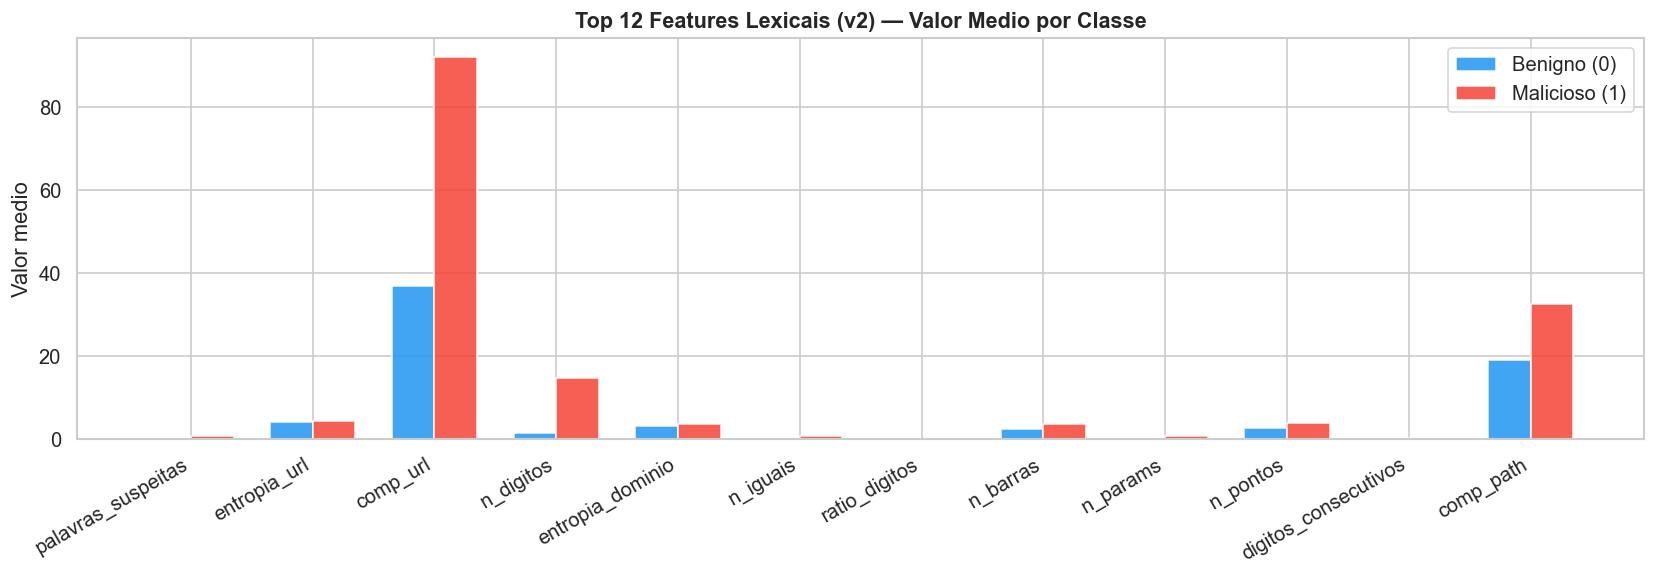

In [11]:
# Gráfico médias por classe (top 12 mais discriminantes)
top12 = corr.abs().sort_values(ascending=False).head(12).index.tolist()
x = range(len(top12))
largura = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - largura/2 for i in x],
       media_classe.loc['Benigno (0)', top12],
       width=largura, label='Benigno (0)', color='#2196F3', alpha=0.85)
ax.bar([i + largura/2 for i in x],
       media_classe.loc['Malicioso (1)', top12],
       width=largura, label='Malicioso (1)', color='#F44336', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('lex_','') for c in top12], rotation=30, ha='right')
ax.set_title('Top 12 Features Lexicais (v2) — Valor Medio por Classe',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Valor medio')
ax.legend()
plt.tight_layout()
plt.savefig('fig_features_v2_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Exportação

In [12]:
# Guardar apenas as features lexicais + label (sem as originais do dataset)
colunas_guardar = features_df.columns.tolist() + ['label']
df_final[colunas_guardar].to_csv('urldata_features_v2.csv', index=False, encoding='utf-8')

# Guardar também o dataset completo (com todas as colunas)
df_final.to_csv('urldata_features_v2_completo.csv', index=False, encoding='utf-8')

print(f'Guardado: urldata_features_v2.csv')
print(f'  {len(df_final):,} linhas x {len(colunas_guardar)} colunas (27 features + label)')

Guardado: urldata_features_v2.csv
  95,911 linhas x 28 colunas (27 features + label)


## 9. Resumo

In [13]:
print('=' * 55)
print('  RESUMO - FEATURE ENGINEERING v2 (PASSO 2B v2)')
print('=' * 55)
print(f'  Features extraidas : 27 (vs. 10 na versao anterior)')
print(f'  Grupos:')
print(f'    Comprimentos     : 3  (url, dominio, path)')
print(f'    Contagens        : 9  (pontos, hifenes, barras, =, &, %, _, params, digitos)')
print(f'    Ratios           : 2  (digitos/url, especiais/url)')
print(f'    Estrutura        : 1  (profundidade do path)')
print(f'    Binarios         : 8  (https, ip, @, http_path, tld, encurtador, porto, digitos_consec.)')
print(f'    Semantico        : 1  (palavras suspeitas)')
print(f'    Entropia         : 2  (dominio, url completo)')
print(f'  Ficheiro gerado    : urldata_features_v2.csv')
print('=' * 55)
print('Proximo passo: Passo3_v2 - Treino do Modelo Lexical')

  RESUMO - FEATURE ENGINEERING v2 (PASSO 2B v2)
  Features extraidas : 27 (vs. 10 na versao anterior)
  Grupos:
    Comprimentos     : 3  (url, dominio, path)
    Contagens        : 9  (pontos, hifenes, barras, =, &, %, _, params, digitos)
    Ratios           : 2  (digitos/url, especiais/url)
    Estrutura        : 1  (profundidade do path)
    Binarios         : 8  (https, ip, @, http_path, tld, encurtador, porto, digitos_consec.)
    Semantico        : 1  (palavras suspeitas)
    Entropia         : 2  (dominio, url completo)
  Ficheiro gerado    : urldata_features_v2.csv
Proximo passo: Passo3_v2 - Treino do Modelo Lexical
